<a href="https://colab.research.google.com/github/SuchandanG/Unified-Algebraic-Framework-for-Entanglement-Certification-and-Linear-Time-Error-Correction-for-SSE/blob/main/A_Unified_Algebraic_Framework_for_Entanglement_Certification_and_Linear_Time_Error_Correction_for_Structured_Simplex_Entanglements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SCP Construction and entanglement witness for GHZ state

Chosen K = 3
lambda_max = 3.0000000000000013
Chosen epsilon = 0.32999999999999985


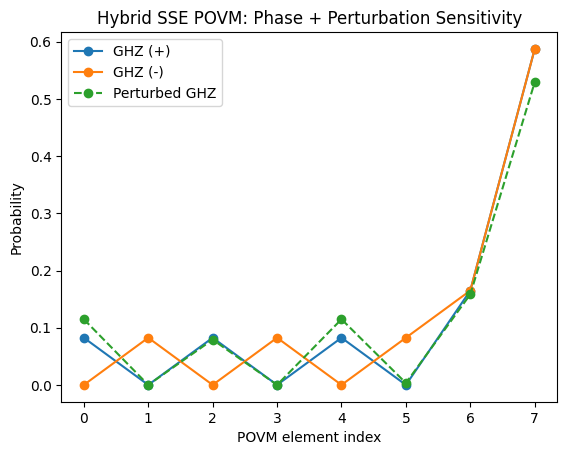


Difference norms:
GHZ vs GHZ- : 0.20208290377961202
GHZ vs Perturbed : 0.07435012988848709
GHZ- vs Perturbed : 0.23652995398891524

Measurement basis vectors (nonzero entries):

Psi_0: indices [0 1 2 3 7], norm=1.0000
Psi_1: indices [0 2 3 4 7], norm=1.0000
Psi_2: indices [0 3 4 5 7], norm=1.0000
Psi_3: indices [0 4 5 6 7], norm=1.0000
Psi_4: indices [0 1 5 6 7], norm=1.0000
Psi_5: indices [0 1 2 6 7], norm=1.0000
Psi_6: indices [7], norm=1.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Basis -----
def basis_state(index, dim):
    v = np.zeros(dim)
    v[index] = 1
    return v

dim = 8

# ----- GHZ states -----
GHZ = (basis_state(0, dim) + basis_state(7, dim)) / np.sqrt(2)
GHZ_minus = (basis_state(0, dim) - basis_state(7, dim)) / np.sqrt(2)

# ----- Fourier-labelled SSE states -----
Psi_u = [GHZ, GHZ_minus]

# ----- Complement set -----
perp_indices = [1,2,3,4,5,6]
N = len(perp_indices)

# ----- Choose K -----
K = 3
print("Chosen K =", K)

# ----- Generate cyclic subsets -----
T_list = []
for i in range(N):
    subset = []
    for j in range(K):
        subset.append(perp_indices[(i + j) % N])
    T_list.append(subset)

# ----- Construct Psi_i -----
Psi = []

for i in range(N):
    u_i = i % 2
    vec = Psi_u[u_i].copy()

    for j in T_list[i]:
        vec += basis_state(j, dim)

    vec = vec / np.linalg.norm(vec)
    Psi.append(vec)

# ----- Add solution basis -----
Psi.append(basis_state(7, dim))  # |111>

# ----- Build operators -----
tilde_E = [np.outer(p, np.conj(p)) for p in Psi]
A = sum(tilde_E)

# ----- Spectral bound -----
eigvals = np.linalg.eigvals(A)
lambda_max = np.max(np.real(eigvals))

epsilon = 0.99 / lambda_max

print("lambda_max =", lambda_max)
print("Chosen epsilon =", epsilon)

# ----- POVM -----
E = [epsilon * Ei for Ei in tilde_E]
E.append(np.eye(dim) - epsilon * A)

# ----- Probability function -----
def probs(state):
    return [np.real(np.conj(state) @ Ei @ state) for Ei in E]

# ----- Perturbed state -----
eta = 0.2
perturb = basis_state(1, dim)  # |001>
Phi = np.sqrt(1 - eta**2) * GHZ + eta * perturb
Phi = Phi / np.linalg.norm(Phi)

# ----- Compute probabilities -----
p_GHZ = probs(GHZ)
p_minus = probs(GHZ_minus)
p_perturb = probs(Phi)

# ----- Plot all together -----
x = np.arange(len(E))

plt.figure()
plt.plot(x, p_GHZ, marker='o', label='GHZ (+)')
plt.plot(x, p_minus, marker='o', label='GHZ (-)')
plt.plot(x, p_perturb, marker='o', linestyle='--', label='Perturbed GHZ')

plt.xlabel('POVM element index')
plt.ylabel('Probability')
plt.title('Hybrid SSE POVM: Phase + Perturbation Sensitivity')
plt.legend()
plt.show()

# ----- Differences -----
print("\nDifference norms:")
print("GHZ vs GHZ- :", np.linalg.norm(np.array(p_GHZ) - np.array(p_minus)))
print("GHZ vs Perturbed :", np.linalg.norm(np.array(p_GHZ) - np.array(p_perturb)))
print("GHZ- vs Perturbed :", np.linalg.norm(np.array(p_minus) - np.array(p_perturb)))

# ----- Print measurement vectors -----
print("\nMeasurement basis vectors (nonzero entries):\n")
for idx, vec in enumerate(Psi):
    nz = np.nonzero(np.abs(vec) > 1e-6)[0]
    print(f"Psi_{idx}: indices {nz}, norm={np.linalg.norm(vec):.4f}")

SCP Construction and entanglement witness for Bell state

Chosen K = 1
lambda_max = 1.7071067811865475
Chosen epsilon = 0.579928573250636


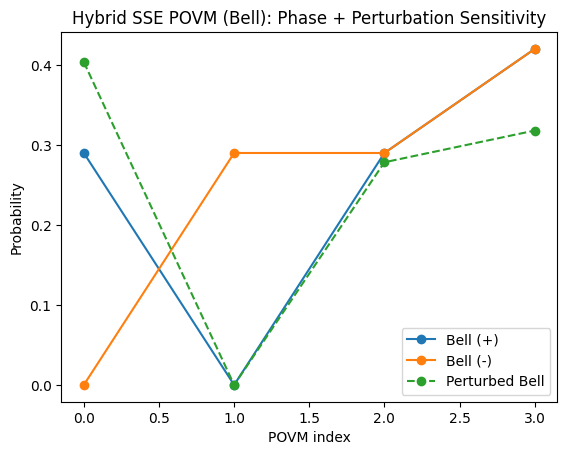


Difference norms:
Bell vs Bell- : 0.410071426749364
Bell vs Perturbed : 0.1531732141579211
Bell- vs Perturbed : 0.5074692516061478

Measurement basis vectors:

Psi_0: indices [0 1 3], norm=1.0000
Psi_1: indices [0 2 3], norm=1.0000
Psi_2: indices [3], norm=1.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Basis -----
def basis_state(index, dim):
    v = np.zeros(dim)
    v[index] = 1
    return v

dim = 4

# ----- Bell states -----
Bell = (basis_state(0, dim) + basis_state(3, dim)) / np.sqrt(2)
Bell_minus = (basis_state(0, dim) - basis_state(3, dim)) / np.sqrt(2)

# Fourier-labelled SSE
Psi_u = [Bell, Bell_minus]

# ----- Complement -----
perp_indices = [1, 2]  # |01>, |10>
N = len(perp_indices)

# ----- Choose K -----
K = 1
print("Chosen K =", K)

# ----- Subsets -----
T_list = [[perp_indices[i]] for i in range(N)]

# ----- Build Psi_i -----
Psi = []

for i in range(N):
    u_i = i % 2
    vec = Psi_u[u_i].copy()

    for j in T_list[i]:
        vec += basis_state(j, dim)

    vec = vec / np.linalg.norm(vec)
    Psi.append(vec)

# ----- Add solution basis -----
Psi.append(basis_state(3, dim))  # |11>

# ----- Build operators -----
tilde_E = [np.outer(p, np.conj(p)) for p in Psi]
A = sum(tilde_E)

eigvals = np.linalg.eigvals(A)
lambda_max = np.max(np.real(eigvals))

epsilon = 0.99 / lambda_max

print("lambda_max =", lambda_max)
print("Chosen epsilon =", epsilon)

# ----- POVM -----
E = [epsilon * Ei for Ei in tilde_E]
E.append(np.eye(dim) - epsilon * A)

# ----- Probability function -----
def probs(state):
    return [np.real(np.conj(state) @ Ei @ state) for Ei in E]

# ----- Perturbed Bell state -----
eta = 0.2
perturb = basis_state(1, dim)  # |01>

Phi = np.sqrt(1 - eta**2) * Bell + eta * perturb
Phi = Phi / np.linalg.norm(Phi)

# ----- Compute -----
p_plus = probs(Bell)
p_minus = probs(Bell_minus)
p_perturb = probs(Phi)

# ----- Plot all three -----
x = np.arange(len(E))

plt.figure()
plt.plot(x, p_plus, marker='o', label='Bell (+)')
plt.plot(x, p_minus, marker='o', label='Bell (-)')
plt.plot(x, p_perturb, marker='o', linestyle='--', label='Perturbed Bell')

plt.xlabel('POVM index')
plt.ylabel('Probability')
plt.title('Hybrid SSE POVM (Bell): Phase + Perturbation Sensitivity')
plt.legend()
plt.show()

# ----- Differences -----
print("\nDifference norms:")
print("Bell vs Bell- :", np.linalg.norm(np.array(p_plus) - np.array(p_minus)))
print("Bell vs Perturbed :", np.linalg.norm(np.array(p_plus) - np.array(p_perturb)))
print("Bell- vs Perturbed :", np.linalg.norm(np.array(p_minus) - np.array(p_perturb)))

# ----- Print measurement vectors -----
print("\nMeasurement basis vectors:\n")
for idx, vec in enumerate(Psi):
    nz = np.nonzero(np.abs(vec) > 1e-6)[0]
    print(f"Psi_{idx}: indices {nz}, norm={np.linalg.norm(vec):.4f}")

SCP and Bell basis comparison for small deviations

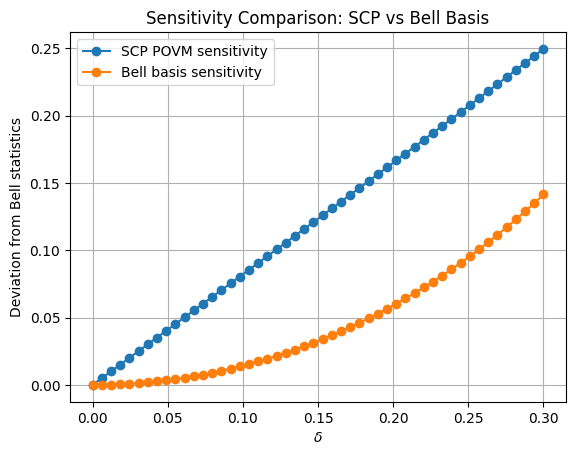

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Basis -----
def basis_state(index, dim):
    v = np.zeros(dim)
    v[index] = 1
    return v

dim = 4

# ----- Bell states -----
Bell = (basis_state(0, dim) + basis_state(3, dim)) / np.sqrt(2)
Bell_minus = (basis_state(0, dim) - basis_state(3, dim)) / np.sqrt(2)

# Full Bell basis
Bell_basis = [
    Bell,
    Bell_minus,
    (basis_state(1, dim) + basis_state(2, dim)) / np.sqrt(2),
    (basis_state(1, dim) - basis_state(2, dim)) / np.sqrt(2)
]

Bell_projectors = [np.outer(b, np.conj(b)) for b in Bell_basis]

# ----- SCP construction -----
Psi_u = [Bell, Bell_minus]
perp_indices = [1, 2]

T_list = [[1], [2]]

Psi = []
for i in range(len(T_list)):
    u_i = i % 2
    vec = Psi_u[u_i].copy()
    for j in T_list[i]:
        vec += basis_state(j, dim)
    vec = vec / np.linalg.norm(vec)
    Psi.append(vec)

# Add solution basis
Psi.append(basis_state(3, dim))  # |11>

tilde_E = [np.outer(p, np.conj(p)) for p in Psi]
A = sum(tilde_E)

lambda_max = np.max(np.real(np.linalg.eigvals(A)))
epsilon = 0.99 / lambda_max

E_scp = [epsilon * Ei for Ei in tilde_E]
E_scp.append(np.eye(dim) - epsilon * A)

# ----- Probability functions -----
def probs(state, POVM):
    return np.array([np.real(np.conj(state) @ Ei @ state) for Ei in POVM])

# ----- Sweep delta -----
deltas = np.linspace(0, 0.3, 50)

scp_diff = []
bell_diff = []

p_ref_scp = probs(Bell, E_scp)
p_ref_bell = probs(Bell, Bell_projectors)

for delta in deltas:
    psi = np.sqrt(0.5 + delta) * basis_state(0, dim) + \
          np.sqrt(0.5 - delta) * basis_state(3, dim)
    psi = psi / np.linalg.norm(psi)

    p_scp = probs(psi, E_scp)
    p_bell = probs(psi, Bell_projectors)

    # deviation from ideal Bell
    scp_diff.append(np.linalg.norm(p_scp - p_ref_scp))
    bell_diff.append(np.linalg.norm(p_bell - p_ref_bell))

# ----- Plot -----
plt.figure()
plt.plot(deltas, scp_diff, label='SCP POVM sensitivity', marker='o')
plt.plot(deltas, bell_diff, label='Bell basis sensitivity', marker='o')

plt.xlabel(r'$\delta$')
plt.ylabel('Deviation from Bell statistics')
plt.title('Sensitivity Comparison: SCP vs Bell Basis')
plt.legend()
plt.grid()
plt.show()

SSE error Correction

Valid SSE basis states: [1, 6]


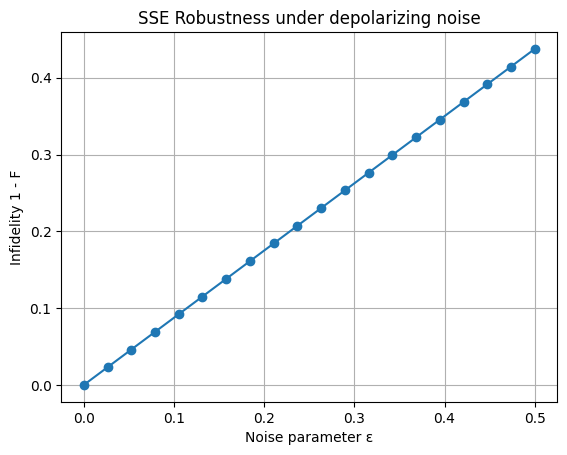

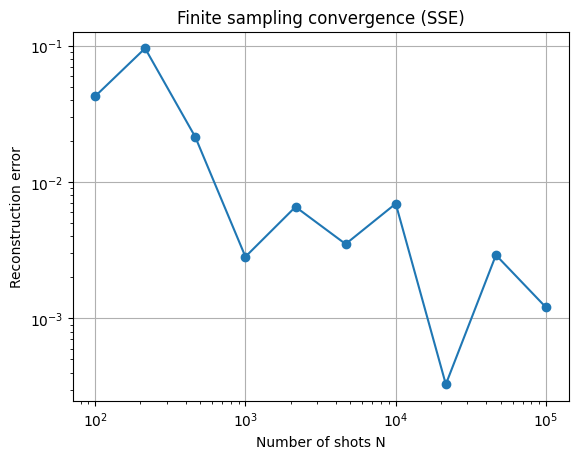

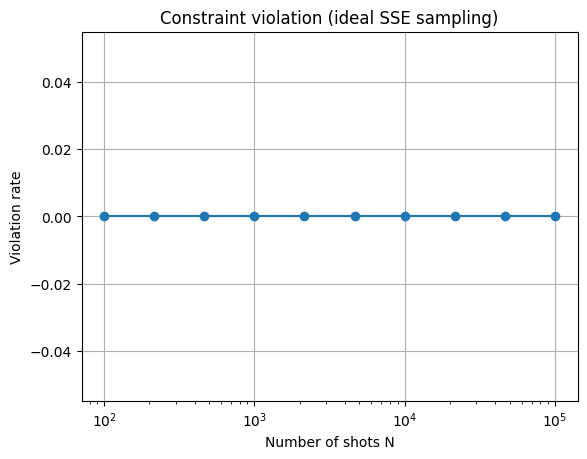

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# ============================================================
# 1. Generate SSE state from linear constraints Ax = b (mod 2)
# ============================================================
def generate_sse_state(m, A, b):
    solutions = []

    # iterate over all bitstrings
    for x in product([0, 1], repeat=m):
        x_vec = np.array(x)

        if np.all((A @ x_vec) % 2 == b % 2):
            idx = int("".join(map(str, x)), 2)
            solutions.append(idx)

    dim = 2**m
    psi = np.zeros(dim)

    for idx in solutions:
        psi[idx] = 1

    psi = psi / np.linalg.norm(psi)

    return psi, solutions


# ============================================================
# 2. Fidelity function
# ============================================================
def fidelity(psi, rho):
    return np.real(np.conj(psi) @ rho @ psi)


# ============================================================
# 3. Constraint violation checker
# ============================================================
def constraint_violation_rate(sample_indices, m, A, b):
    violations = 0

    for idx in sample_indices:
        bitstring = format(idx, f'0{m}b')
        x_vec = np.array(list(map(int, bitstring)))

        if not np.all((A @ x_vec) % 2 == b % 2):
            violations += 1

    return violations / len(sample_indices)


# ============================================================
# 4. PARAMETERS (nontrivial SSE example)
# ============================================================
m = 3

A = np.array([
    [1, 1, 0],
    [0, 1, 1]
])

b = np.array([0, 1])

psi, solutions = generate_sse_state(m, A, b)
dim = len(psi)

print("Valid SSE basis states:", solutions)


# ============================================================
# 5. EXPERIMENT 1: Noise robustness (depolarizing)
# ============================================================
epsilons = np.linspace(0, 0.5, 20)
infidelity = []

for eps in epsilons:
    rho = (1 - eps) * np.outer(psi, psi) + eps * np.eye(dim) / dim
    F = fidelity(psi, rho)
    infidelity.append(1 - F)

plt.figure()
plt.plot(epsilons, infidelity, marker='o')
plt.xlabel("Noise parameter ε")
plt.ylabel("Infidelity 1 - F")
plt.title("SSE Robustness under depolarizing noise")
plt.grid()
plt.show()


# ============================================================
# 6. EXPERIMENT 2: Finite sampling + reconstruction error
# ============================================================
shots = np.logspace(2, 5, 10, dtype=int)
errors = []
violation_rates = []

true_prob = np.abs(psi)**2

for N in shots:
    # sample outcomes
    sampled_counts = np.random.multinomial(N, true_prob)
    sampled_prob = sampled_counts / N

    # reconstruction error (L2 norm)
    error = np.linalg.norm(sampled_prob - true_prob)
    errors.append(error)

    # generate sample indices explicitly for violation check
    sampled_indices = []
    for idx, count in enumerate(sampled_counts):
        sampled_indices.extend([idx] * count)

    violation = constraint_violation_rate(sampled_indices, m, A, b)
    violation_rates.append(violation)


# ============================================================
# 7. Plot sampling error
# ============================================================
plt.figure()
plt.loglog(shots, errors, marker='o')
plt.xlabel("Number of shots N")
plt.ylabel("Reconstruction error")
plt.title("Finite sampling convergence (SSE)")
plt.grid()
plt.show()


# ============================================================
# 8. Plot constraint violation rate
# ============================================================
plt.figure()
plt.semilogx(shots, violation_rates, marker='o')
plt.xlabel("Number of shots N")
plt.ylabel("Violation rate")
plt.title("Constraint violation (ideal SSE sampling)")
plt.grid()
plt.show()

FSC for Bell and GHZ state

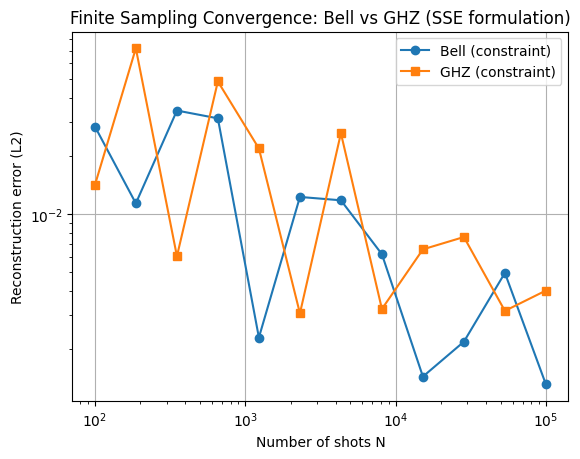

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# ============================================================
# 1. SSE generator (Ax = b mod 2)
# ============================================================
def generate_sse_state(m, A, b):
    solutions = []

    for x in product([0, 1], repeat=m):
        x_vec = np.array(x)

        if np.all((A @ x_vec) % 2 == b % 2):
            idx = int("".join(map(str, x)), 2)
            solutions.append(idx)

    dim = 2**m
    psi = np.zeros(dim)

    for idx in solutions:
        psi[idx] = 1

    psi = psi / np.linalg.norm(psi)
    return psi


# ============================================================
# 2. Define Bell and GHZ via constraints
# ============================================================

# Bell: x1 + x2 = 0
A_bell = np.array([[1, 1]])
b_bell = np.array([0])
psi_bell = generate_sse_state(2, A_bell, b_bell)

# GHZ (3 qubits): x1+x2=0, x1+x3=0
A_ghz = np.array([
    [1, 1, 0],
    [1, 0, 1]
])
b_ghz = np.array([0, 0])
psi_ghz = generate_sse_state(3, A_ghz, b_ghz)


# ============================================================
# 3. Finite sampling experiment
# ============================================================
shots = np.logspace(2, 5, 12, dtype=int)

errors_bell = []
errors_ghz = []

true_prob_bell = np.abs(psi_bell)**2
true_prob_ghz = np.abs(psi_ghz)**2

for N in shots:
    # Bell sampling
    sampled_bell = np.random.multinomial(N, true_prob_bell) / N
    error_bell = np.linalg.norm(sampled_bell - true_prob_bell)
    errors_bell.append(error_bell)

    # GHZ sampling
    sampled_ghz = np.random.multinomial(N, true_prob_ghz) / N
    error_ghz = np.linalg.norm(sampled_ghz - true_prob_ghz)
    errors_ghz.append(error_ghz)


# ============================================================
# 4. Plot
# ============================================================
plt.figure()

plt.loglog(shots, errors_bell, marker='o', label='Bell (constraint)')
plt.loglog(shots, errors_ghz, marker='s', label='GHZ (constraint)')

plt.xlabel("Number of shots N")
plt.ylabel("Reconstruction error (L2)")
plt.title("Finite Sampling Convergence: Bell vs GHZ (SSE formulation)")
plt.legend()
plt.grid()
plt.show()

Error correction before and after correction procedure for the EPS
\begin{cases}
x_1 + x_2 + t_1 = 0 \\
x_1 + t_2 = 0
\end{cases}

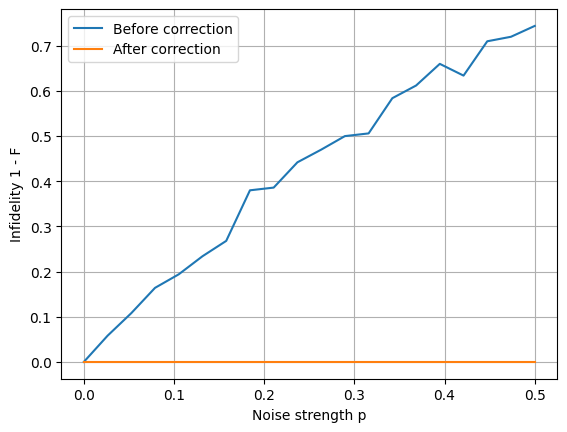

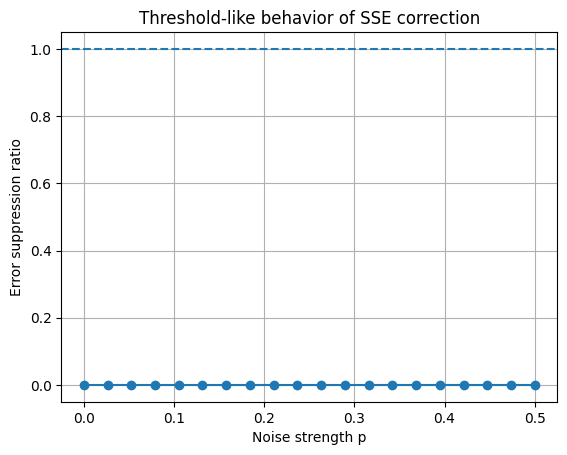

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Define SSE system
# Example: 2 control (x1,x2), 2 target (t1,t2)
# t1 = x1 ⊕ x2
# t2 = x1
# ----------------------------

def generate_sse_state():
    states = []
    for x1 in [0,1]:
        for x2 in [0,1]:
            t1 = (x1 ^ x2)
            t2 = x1
            states.append([x1,x2,t1,t2])
    return np.array(states)

# Ideal SSE state vector
def state_vector(states):
    dim = 2**len(states[0])
    psi = np.zeros(dim)
    for s in states:
        idx = int("".join(map(str,s)),2)
        psi[idx] = 1
    return psi / np.sqrt(len(states))

# Fidelity
def fidelity(psi, rho):
    return np.real(np.conj(psi) @ rho @ psi)

# ----------------------------
# Syndrome extraction (s = Me)
# Here M_t = I => s = error on targets
# ----------------------------
def syndrome(error):
    # last 2 bits are targets
    return error[2:]

# Correction: flip targets where syndrome = 1
def correct(error):
    corrected = error.copy()
    s = syndrome(error)
    corrected[2:] = (corrected[2:] + s) % 2
    return corrected

# Apply error to state basis index
def apply_error(state, error):
    return (state + error) % 2

# ----------------------------
# Simulation
# ----------------------------
states = generate_sse_state()
psi = state_vector(states)

p_vals = np.linspace(0,0.5,20)
F_raw = []
F_corr = []

for p in p_vals:
    trials = 500
    f_raw = 0
    f_corr = 0

    for _ in range(trials):
        # pick random valid SSE basis state
        s = states[np.random.randint(len(states))]

        # random bit-flip error on target qubits
        error = np.zeros(4, dtype=int)
        for i in [2,3]:  # target indices
            if np.random.rand() < p:
                error[i] = 1

        noisy = apply_error(s, error)

        # raw fidelity: check if still valid SSE state
        f_raw += int(any((noisy == st).all() for st in states))

        # correction
        corrected_error = correct(error)
        corrected = apply_error(s, corrected_error)

        f_corr += int(any((corrected == st).all() for st in states))

    F_raw.append(f_raw/trials)
    F_corr.append(f_corr/trials)

# Plot
plt.figure()
plt.plot(p_vals, 1-np.array(F_raw), label="Before correction")
plt.plot(p_vals, 1-np.array(F_corr), label="After correction")
plt.xlabel("Noise strength p")
plt.ylabel("Infidelity 1 - F")
plt.legend()
plt.grid()
plt.show()
# ==========================================
# THRESHOLD-LIKE BEHAVIOR
# ==========================================

F_raw_arr = np.array(F_raw)
F_corr_arr = np.array(F_corr)

ratio = (1 - F_corr_arr) / (1 - F_raw_arr + 1e-10)  # avoid divide by zero

plt.figure()
plt.plot(p_vals, ratio, marker='o')
plt.axhline(1.0, linestyle='--')  # threshold line
plt.xlabel("Noise strength p")
plt.ylabel("Error suppression ratio")
plt.title("Threshold-like behavior of SSE correction")
plt.grid()
plt.show()